In [ ]:
!pip install 'transformers<5.0.0'

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import importlib
import transformers
importlib.reload(transformers)
print(transformers.__version__)

4.57.6


In [5]:
MODEL_NAME = "google/gemma-3-4b-it"

In [ ]:
from transformers import pipeline

pipe = pipeline("text-generation", model=MODEL_NAME, return_full_text = False)

In [7]:
def generate_score(question, answer, context=[], min_score=0, max_score=5):
  # Note: Hanya jawab dengan sebuah angka dari {min_score} sampai {max_score} (Contoh: {max_score}). Tidak menjelaskan atau memasukkan teks lain.
    score = pipe([
        {
            "role": "system",
            "content": "Kamu adalah evaluator yang kritis, tegas, dan adil dalam memberikan jawaban dan menyesuaikan dengan fakta dan kriteria yang berlaku. Jika jawaban hanya berisi '-', kosong, atau tidak menjawab pertanyaan, maka berikan skor rendah menyesuaikan apa yang ditulis."
        },
        {
            'role': 'user',
            'content': f"""
                Diberikan data terdiri atas pertanyaan, dan jawaban. evaluasi jawaban ini dan berikan skor dari {min_score} sampai dengan {max_score} dengan kriteria berikut:
                - Jawaban tidak boleh hanya berisi '-', kosong, atau tidak menjawab pertanyaan, jika demikian berikan skor {min_score}.
                - Jawaban harus sesuai dengan konteks
                - Penulisan jawaban harus sesuai dengan kaidah penulisan bahasa Indonesia dan typo pada jawabannya

                Instruksi:
                Baca pertanyaan dan jawabannya. Kemudian lakukan analisa terkait jawaban apakah memenuhi kriteria pertama atau tidak. Selanjutnya, bandingkan jawaban dengan konteks untuk melihat apakah sesuai atau tidak, jika tidak sesuai akan mendapatkan pengurangan nilai. Terakhir cek penulisan jawaban, jika tidak sesuai akan mendapatkan pengurangan nilai.

                Berikan output dalam format berikut:
                Penjelasan: <analisa jawaban berdasarkan instruksi>
                Skor: <nilai untuk jawaban dari {min_score} - {max_score}>
                \n
                Pertanyaan: {question}
                Jawaban: '{answer}'

                {"Konteks:\n" + "\n".join(context) if len(context) >= 1 else ""}
            """,
        },
    ], max_new_tokens=1024)
    return score[0]['generated_text']

In [8]:
import pandas as pd
import os

def prepare_data(path):
    all_sheets_dict = pd.read_excel(path,
                                    sheet_name=None, skiprows=1)

    for key in all_sheets_dict.keys():
        df = all_sheets_dict[key]
        new_df = df.drop(df.columns[0], axis=1)
        all_sheets_dict[key] = new_df

    soal_list = list(all_sheets_dict.keys())[1:-1]

    for idx, num in enumerate(soal_list):
        ans_data = all_sheets_dict[num].dropna()
        ans_data

    ref_df = all_sheets_dict['Soal']
    for idx, num in enumerate(soal_list):
        data = all_sheets_dict[num].dropna()
        data = data.copy()
        data.columns = [col.replace(' ', '') for col in data.columns]
        if 'o' in data.columns: print(num)

        key = 'Soal' if 'Soal' in ref_df.loc[idx].keys() else 'Soal '

        soal = ref_df.loc[idx,key]
        kunjaw = ref_df.loc[idx,'Kunci Jawaban']
        data.loc[:,'Soal'] = soal
        data.loc[:,'Kunci Jawaban'] = kunjaw
        all_sheets_dict[num] = data


    df = pd.concat([all_sheets_dict[num] for num in soal_list], ignore_index=True)
    df.drop_duplicates()
    return df

DATASET_PATH = '/content/drive/MyDrive/THESIS-Dataset'

type_list = []
df_list = []
for filename in os.listdir(DATASET_PATH):
    file = os.path.join(DATASET_PATH, filename)
    type_list.append(filename.split("_")[-1].replace("xlsx", ""))
    data = prepare_data(file)
    df = data[['Jawaban', 'RataManual', 'Soal', 'Kunci Jawaban']]

    df = df.drop_duplicates()
    df_list.append(df)
    print(f"{filename}: {df.shape}")

merged = pd.concat(df_list, ignore_index=True)
merged.tail()

No.3
Analisis_Essay_Grading_Olahraga.xlsx: (529, 4)
Analisis_Essay_Grading_Lifestyle.xlsx: (560, 4)
Analisis_Essay_Grading_Politik.xlsx: (532, 4)
Analisis_Essay_Grading_Teknologi.xlsx: (501, 4)


,Jawaban,RataManual,Soal,Kunci Jawaban
2117,bluetooth adalah personal area network yang te...,18.333333,Apa yang dimaksud dengan Bluetooth?,Bluetooth adalah perangkat yang menjadi media ...
2118,spesifikasi industri untuk jaringan kawasan pr...,41.666667,Apa yang dimaksud dengan Bluetooth?,Bluetooth adalah perangkat yang menjadi media ...
2119,sebagai teknologi komunikasi wireless (tanpa k...,26.666667,Apa yang dimaksud dengan Bluetooth?,Bluetooth adalah perangkat yang menjadi media ...
2120,digunakan untuk transfer data berupa file dan ...,29.333333,Apa yang dimaksud dengan Bluetooth?,Bluetooth adalah perangkat yang menjadi media ...
2121,bluetooth adalah koneksi ke bluetooth lain tan...,22.666667,Apa yang dimaksud dengan Bluetooth?,Bluetooth adalah perangkat yang menjadi media ...


In [17]:
import os

OUT_PATH = '/content/drive/MyDrive/rahutomo-scoring-out'
res_df = []
for idx,_ in enumerate(os.listdir(OUT_PATH)):
  res_df.append(pd.read_csv(f"{OUT_PATH}/rehutomo-scoring-out-no-reasoning-batch-{idx}.csv"))

all_df = pd.concat(res_df)

In [10]:
test = merged[merged['Soal'] == all_df.iloc[-1]['Soal']]

last_answered_idx = all_df[all_df['Soal'] == all_df.iloc[-1]['Soal']]

len(last_answered_idx)

46

In [11]:
# Ambil dari pertanyaan yang belum dieval
uneval_data = merged[~merged['Soal'].isin(all_df['Soal'])]

# Ambil dari jawaban yang belum dieval

partial_eval_data = test.iloc[len(last_answered_idx):]

uneval_df = pd.concat([partial_eval_data, uneval_data])

In [ ]:
import numpy as np

batch_idxs = np.linspace(0, len(merged['Soal']), 21, dtype=int)
print(batch_idxs)

[   0  106  212  318  424  530  636  742  848  954 1061 1167 1273 1379
 1485 1591 1697 1803 1909 2015 2122]


In [12]:
import numpy as np

batch_idxs = np.linspace(0, len(uneval_df['Soal']), 21 - len(res_df), dtype=int)
print(batch_idxs)

[  0 106 212 319]


In [ ]:

for idx in range(1, len(batch_idxs) - 1):
  scores = []
  # print(batch_idxs[idx], batch_idxs[idx+1])
  # scores = np.zeros(batch_idxs[idx+1] - batch_idxs[idx])
  for i in range(batch_idxs[idx], batch_idxs[idx + 1]):

    data = merged.iloc[i]
    score = generate_score(data['Soal'], data['Jawaban'], context=[data['Kunci Jawaban']], max_score = 100)
    scores.append(score)

    print(f"Score: {data['RataManual']}, Predicted: {score}")

  saved = merged.iloc[batch_idxs[idx]:batch_idxs[idx + 1]]
  saved['Prediksi'] = scores
  saved.to_csv(f'/content/drive/MyDrive/rehutomo-scoring-out-no-reasoning-batch-{idx}.csv', index=False)

In [14]:
for idx in range(0, len(batch_idxs) - 1):
  scores = []
  # print(batch_idxs[idx], batch_idxs[idx+1])
  # scores = np.zeros(batch_idxs[idx+1] - batch_idxs[idx])
  for i in range(batch_idxs[idx], batch_idxs[idx + 1]):

    data = uneval_df.iloc[i]
    score = generate_score(data['Soal'], data['Jawaban'], context=[data['Kunci Jawaban']], max_score = 100)
    scores.append(score)

    print(f"Score: {data['RataManual']}, Predicted: {score}")

  saved = uneval_df.iloc[batch_idxs[idx]:batch_idxs[idx + 1]]
  saved['Prediksi'] = scores
  saved.to_csv(f'/content/drive/MyDrive/rahutomo-scoring-out/rehutomo-scoring-out-no-reasoning-batch-{idx + len(res_df)}.csv', index=False)

Score: 40.666666666666664, Predicted: Penjelasan: Jawaban ini memberikan definisi dasar mengenai block dalam bola voli dan menyebutkan posisi yang umumnya melakukan block. Namun, jawaban tersebut kurang lengkap karena tidak menjelaskan secara rinci bagaimana block dilakukan dan secara spesifik menyebutkan posisi pemain yang melakukan block (posisi 4 dan 2 kurang tepat, karena block biasanya dilakukan oleh semua pemain di barisan depan). Selain itu, terdapat sedikit ketidaksesuaian dengan konteks karena libero memang sering melakukan block, namun bukan satu-satunya pemain yang melakukan block.

Skor: 70
Score: 25.666666666666668, Predicted: Penjelasan: Jawaban ini memberikan definisi dasar mengenai block dalam bola voli, yaitu menahan serangan dari lawan. Namun, menyebutkan posisi 4 dan 2 kurang tepat. Block umumnya dilakukan oleh semua pemain, terutama sebagai pemain depan (posisi 3 dan 4), tetapi libero juga memiliki peran penting dalam melakukan block. Penjelasan mengenai cara melaku

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Score: 26.666666666666668, Predicted: Penjelasan: Jawaban ini memberikan definisi yang cukup baik mengenai block dalam bola voli, yaitu upaya menahan serangan lawan. Namun, jawaban tersebut kurang spesifik mengenai posisi yang paling umum melakukan block. Meskipun menyebutkan blocker sebagai pemain yang bisa bertugas sebagai spiker, jawaban tidak secara eksplisit menyatakan bahwa block biasanya dilakukan oleh pemain yang bertugas sebagai blocker (biasanya middle blocker atau opposite hitter). Selain itu, jawaban juga menyebutkan libero, padahal block umumnya dilakukan oleh pemain depan (setter, middle blocker, atau opposite hitter).

Skor: 65
Score: 23.0, Predicted: Penjelasan: Jawaban ini memberikan definisi singkat mengenai fungsi block dalam bola voli, yaitu untuk menggagalkan serangan lawan. Namun, jawaban ini kurang lengkap karena tidak menyebutkan posisi pemain yang biasanya melakukan block. Meskipun disebutkan "biasanya menggunakan kedua tangan", informasi ini tidak cukup untuk 

/tmp/ipykernel_18133/793706622.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['Prediksi'] = scores


Score: 16.666666666666668, Predicted: Penjelasan: Jawaban ini sama sekali tidak relevan dengan pertanyaan. Informasi yang diberikan tentang "Nankatsu", "Tsubasa dan Misaki", "Hyuga dari Toho", dan skor 50-0 tidak berkaitan dengan Cristiano Ronaldo. Jawaban ini juga mengandung kesalahan faktual dan tidak sesuai konteks. Selain itu, gaya penulisan tidak terstruktur dan kurang profesional.

Skor: 0

Score: 56.0, Predicted: Penjelasan: Jawaban ini memberikan informasi yang relevan dan lengkap mengenai Cristiano Ronaldo sesuai dengan pertanyaan yang diajukan. Data yang diberikan meliputi tanggal lahir, kebangsaan, klub saat ini, klub sebelumnya, nomor punggung, dan sebutan yang umum digunakan. Penulisannya juga sudah sesuai dengan kaidah bahasa Indonesia yang baik dan benar, tanpa ada typo.

Skor: 100
Score: 52.666666666666664, Predicted: Penjelasan: Jawaban ini memberikan informasi yang relevan mengenai Cristiano Ronaldo, termasuk tanggal lahir, kebangsaan, klub saat ini, klub sebelumnya, 

/tmp/ipykernel_18133/793706622.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['Prediksi'] = scores


Score: 43.333333333333336, Predicted: Penjelasan: Jawaban ini menjawab pertanyaan dengan menyebutkan tiga hal yang perlu diperhatikan saat memilih kolam renang, yaitu luas kolam, kebersihan air, dan kedalaman. Jawaban ini sesuai dengan konteks yang diberikan, karena ketiga poin tersebut relevan dengan kualitas air dan bentuk/kedalaman kolam. Penulisan juga sudah sesuai dengan kaidah bahasa Indonesia.

Skor: 85

Score: 56.666666666666664, Predicted: Penjelasan: Jawaban ini memberikan beberapa poin yang relevan terkait pemilihan kolam renang, yaitu kualitas air, kebersihan, dan perawatan. Namun, jawaban tersebut kurang spesifik dan tidak mencakup semua aspek penting yang seharusnya diperhatikan. Selain itu, penggunaan tanda kutip pada jawaban juga tidak perlu dan mengurangi kualitas jawaban.

Skor: 70
Score: 70.0, Predicted: Penjelasan: Jawaban ini sudah memenuhi kriteria karena menyebutkan minimal 3 hal yang perlu diperhatikan saat memilih kolam renang, yaitu kedalaman kolam, kualitas a

/tmp/ipykernel_18133/793706622.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  saved['Prediksi'] = scores


In [16]:
import numpy as np

def rmse(actual, predicted):
    return np.sqrt(((predicted - actual) ** 2).mean())

In [28]:
labels = all_df['RataManual']
scores = [int(a[a.find('Skor: '):].replace('Skor: ','').replace('\n','').replace('/100','')) for a in all_df['Prediksi']]
all_df['IntScore'] = scores

In [24]:
res = rmse(labels, scores) / 100
print(f"RMSE: {res:.3f}")

RMSE: 0.309


In [25]:
from scipy.stats import pearsonr
import numpy as np

r, p_value = pearsonr(scores, labels)
print(f"Pearson correlation: {r:.3f}, p-value: {p_value}")

Pearson correlation: 0.616, p-value: 2.3873585525421874e-222


In [30]:
from scipy.stats import spearmanr
import numpy as np

r, p_value = spearmanr(labels, scores)
print(f"Spearman correlation: {r:.3f}, p-value: {p_value}")

Spearman correlation: 0.660, p-value: 7.470366810757526e-266


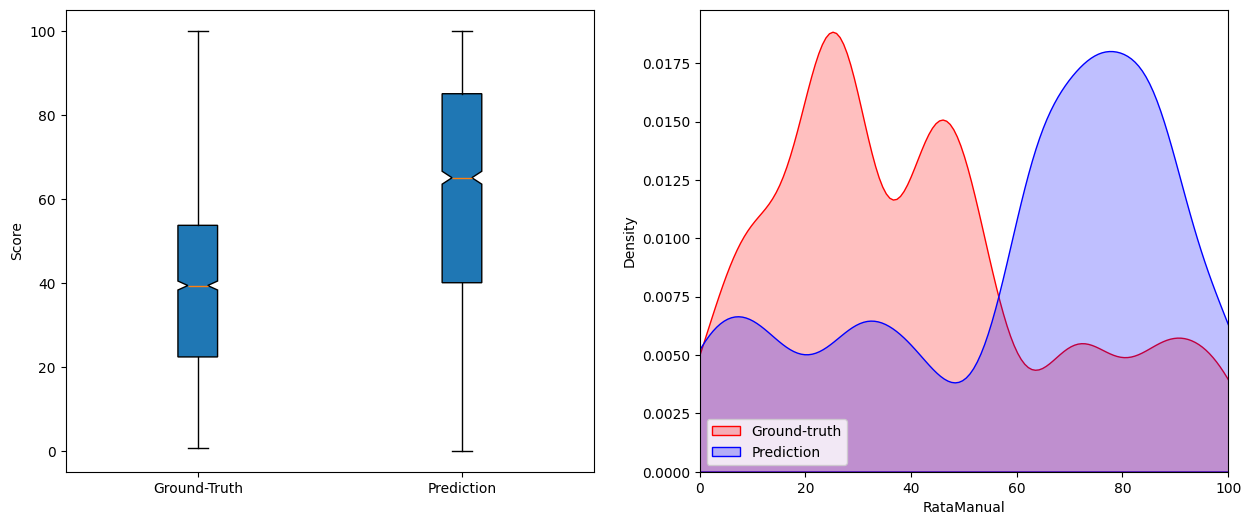

In [29]:
from matplotlib import pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.boxplot([labels, scores], tick_labels=['Ground-Truth', 'Prediction'], notch=True, patch_artist=True)
plt.ylabel('Score')

# plt.subplot(2,2,2)
# plt.ylabel('Score')
# plt.boxplot(scores, notch=True, patch_artist=True)
# plt.title("Prediction")

plt.subplot(1,2,2)
sns.kdeplot(data=all_df, x='RataManual', fill=True, color='red', label='Ground-truth')
sns.kdeplot(data=all_df, x='IntScore', fill=True, color='blue', label='Prediction')
plt.legend()
plt.xlim(0,100)

# plt.subplot(2,2,4)
# sns.kdeplot(data=scores, x='sepal_width', fill=True, color='skyblue')
# plt.title('Prediction')
plt.show()